1. Step
- finding ideal hyperparameters with KFold cross-validation using sklearn implementation of decision tree regressor


 BEST HYPERPARAMETERS FOUND
max_depth = 7
min_leaves = 7
CV R²  = 0.02740


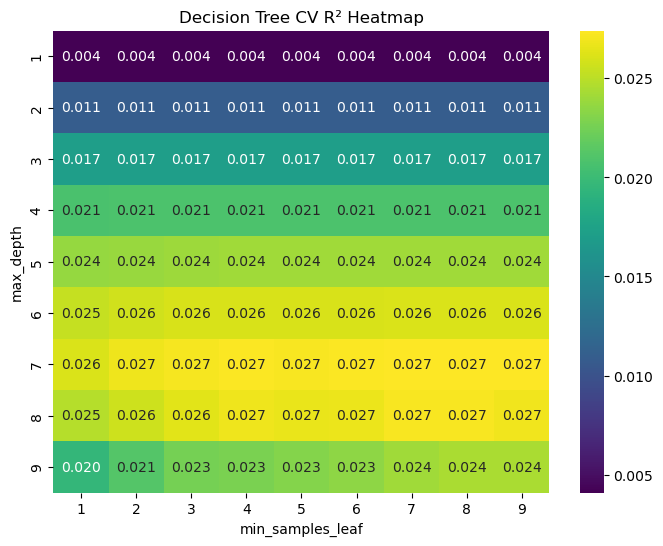

In [18]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# loading the feature engineered dataset
df = pd.read_csv('feature_engineered.csv')

X = df[['Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas']]
X = pd.get_dummies(X, drop_first=True)
y = df['ClaimNb']

X = X.to_numpy()
y = y.to_numpy()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# hyperparameters
max_depth_values = list(range(1, 10))
min_leaf_values = list(range(1, 10))
results = []

# heatmap for plotting
r2_matrix = np.zeros((len(max_depth_values), len(min_leaf_values)))

# cross validation for each hyperparameter combination
for i, d in enumerate(max_depth_values):
    for j, l in enumerate(min_leaf_values):
        r2_scores = []

        for train_index, test_index in kf.split(X):
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            clf = DecisionTreeRegressor(random_state=42, max_depth=d, min_samples_leaf=l)
            clf.fit(X_train, y_train)
            y_hat = clf.predict(X_test)

            r2_scores.append(r2_score(y_test, y_hat))

        avg_r2 = np.mean(r2_scores)
        results.append(((d, l), avg_r2))
        r2_matrix[i, j] = avg_r2

# getting the best result from stored R2 values
best_config = max(results, key=lambda x: x[1])
(best_d, best_l), best_r2 = best_config

print("\n==========================")
print(" BEST HYPERPARAMETERS FOUND")
print("==========================")
print(f"max_depth = {best_d}")
print(f"min_leaves = {best_l}")
print(f"CV R²  = {best_r2:.5f}")
print("==========================")

# plotting the heatmap of R2 values
plt.figure(figsize=(8, 6))
sns.heatmap(r2_matrix, annot=True, fmt=".3f",
            xticklabels=min_leaf_values,
            yticklabels=max_depth_values,
            cmap="viridis")
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.title("Decision Tree CV R² Heatmap")
plt.show()


2. Step
- feature engineering by inspecting the pairplot of features, looking at which combinations of features or their products give better performance score

In [27]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.tree import DecisionTreeRegressor

df = pd.read_csv('feature_engineered.csv')

X = df[['Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas', 'exposure*bonusmalus', 'Density_over_VehAge', 'VehBrand']]
X = pd.get_dummies(X, drop_first=True, dtype=int)
y = df['ClaimNb']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
X = X.to_numpy()
y = y.to_numpy()

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = DecisionTreeRegressor(min_samples_leaf=7, max_depth=7, random_state=42)
    model.fit(X_train, y_train)

    y_hat = model.predict(X_test)

    print(f'R2 score: {r2_score(y_test, y_hat)}')

    print('MSE:', mean_squared_error(y_test, y_hat))


#BEST HYPERPARAMETERS min_samples_leaf=9, max_depth=8 WITH R2 SCORE OF 0.0343 and the feature set:  
#'Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas', 'exposure*bonusmalus', 'Density_over_VehAge', 'VehBrand'

R2 score: 0.026492481739040175
MSE: 0.05423736013104555
R2 score: 0.029167589567023144
MSE: 0.05687300484541594
R2 score: 0.032468881152329265
MSE: 0.05618946645630294
R2 score: 0.030009330110911114
MSE: 0.053070822702927005
R2 score: 0.028976542821240625
MSE: 0.05642527918693718


3. Step
- own raw implementation of a decision tree using the engineered features and best hyperparameters found from previous steps


In [29]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# get the proportions of classes for each region
def proportions(region):
    """Return class 0 and 1 proportions in a region"""
    if len(region) == 0:
        return (0, 0)
    count0 = sum(1 for _, ci in region if ci == 0)
    count1 = sum(1 for _, ci in region if ci == 1)
    total = count0 + count1
    return (count0 / total, count1 / total)

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

# function that chooses which is the best threshold for splitting the feature space
def best_split(X, y):
    n_samples, n_features = X.shape
    best_feature, best_threshold = None, None
    best_rss = float("inf")

    for f in range(n_features):
        # Extract feature + sort once
        feature_values = X[:, f]
        sorted_idx = np.argsort(feature_values)
        fv_sorted = feature_values[sorted_idx]
        y_sorted = y[sorted_idx]

        # Precompute global sums (for right side initially)
        total_count = n_samples
        total_sum = np.sum(y_sorted)
        total_sq_sum = np.sum(y_sorted ** 2)

        # Cumulative sums for left region (initially empty)
        left_count = 0
        left_sum = 0.0
        left_sq_sum = 0.0

        for i in range(n_samples - 1):
            yi = y_sorted[i]

            # Move one sample from right → left
            left_count += 1
            left_sum += yi
            left_sq_sum += yi * yi

            # Right side = global - left
            right_count = total_count - left_count
            if right_count == 0:
                break

            right_sum = total_sum - left_sum
            right_sq_sum = total_sq_sum - left_sq_sum

            # Skip if feature value doesn't change → no valid threshold
            if fv_sorted[i] == fv_sorted[i + 1]:
                continue

            # Compute RSS for left and right using variance formula
            rss_left = left_sq_sum - (left_sum ** 2) / left_count
            rss_right = right_sq_sum - (right_sum ** 2) / right_count
            total_rss = rss_left + rss_right

            if total_rss < best_rss:
                best_rss = total_rss
                best_feature = f
                best_threshold = (fv_sorted[i] + fv_sorted[i + 1]) / 2

    return best_feature, best_threshold

# Recursive Tree Builder 
def build_tree(X, y, depth=0, max_depth=7, min_leaves = 7):
    
    if depth >= max_depth or len(np.unique(y)) == 1 or len(y) < min_leaves:
        return Node(value=np.mean(y))

    feature, threshold = best_split(X, y)
    if feature is None:
        return Node(value=np.mean(y))

    left_idx = X[:, feature] < threshold
    right_idx = X[:, feature] >= threshold

    left = build_tree(X[left_idx], y[left_idx], depth+1, max_depth)
    right = build_tree(X[right_idx], y[right_idx], depth+1, max_depth)
    return Node(feature, threshold, left, right)

# Prediction 
def predict_one(node, x):
    if node.value is not None:
        return node.value
    if x[node.feature] < node.threshold:
        return predict_one(node.left, x)
    else:
        return predict_one(node.right, x)

def predict(node, X):
    return np.array([predict_one(node, x) for x in X])

df = pd.read_csv('feature_engineered.csv')

X = df[['Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas', 'exposure*bonusmalus', 'Density_over_VehAge', 'VehBrand']]
X = pd.get_dummies(X, drop_first=True, dtype="int")
y = df['ClaimNb']

X = X.to_numpy()
y = y.to_numpy()

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    tree = build_tree(X_train, y_train)
    y_pred = predict(tree, X_test)

    print(f'R2 score: {r2_score(y_test, y_pred)}')
    print('MSE:', mean_squared_error(y_test, y_pred))

R2 score: 0.025890717302414323
MSE: 0.054270886440653955
R2 score: 0.028358502217110226
MSE: 0.05692040255101112
R2 score: 0.030101636592032244
MSE: 0.056326944420808205
R2 score: 0.028309092671242042
MSE: 0.053163847308744995
R2 score: 0.028073936922222598
MSE: 0.05647772878480358


4. Step
- make sure the validation and training set has similar performance so that we dont overfit/underfit

In [24]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.tree import DecisionTreeRegressor

df = pd.read_csv('feature_engineered.csv')

# --------------------------
# Features / Target
# --------------------------
X = df[['Density', 'DrivAge', 'Exposure', 'VehAge', 'VehPower',
        'BonusMalus', 'VehGas', 'exposure*bonusmalus',
        'Density_over_VehAge', 'VehBrand']]

X = pd.get_dummies(X, drop_first=True)
y = df['ClaimNb']

# --------------------------
# Train / Validation only
# --------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# --------------------------
# Train model
# --------------------------
clf = DecisionTreeRegressor(random_state=42, min_samples_leaf=7, max_depth=7)
clf.fit(X_train, y_train)

# --------------------------
# Evaluate
# --------------------------
y_pred_train = clf.predict(X_train)
y_pred_val = clf.predict(X_val)

print("--------------- TRAIN SET ---------------")
print("MSE:", mean_squared_error(y_train, y_pred_train))
print(f"R² Score: {r2_score(y_train, y_pred_train):.4f}")

print("\n--------------- VALIDATION SET ---------------")
print("MSE:", mean_squared_error(y_val, y_pred_val))
print(f"R² Score: {r2_score(y_val, y_pred_val):.4f}")


--------------- TRAIN SET ---------------
MSE: 0.05480842297879076
R² Score: 0.0387

--------------- VALIDATION SET ---------------
MSE: 0.05540028052192793
R² Score: 0.0301


--------------- TRAIN SET ---------------
MSE: 0.0544499912766872
R² Score: 0.0418

--------------- VALIDATION SET ---------------
MSE: 0.05561354722373212
R² Score: 0.0343



--------------- TRAIN SET ---------------
MSE: 0.05450734167966135
R² Score: 0.0440

--------------- VALIDATION SET ---------------
MSE: 0.05543336212926447
R² Score: 0.0295

7/7

--------------- TRAIN SET ---------------
MSE: 0.05480842297879076
R² Score: 0.0387

--------------- VALIDATION SET ---------------
MSE: 0.05540028052192793
R² Score: 0.0301


==========================
 BEST HYPERPARAMETERS FOUND
==========================
max_depth = 8
min_leaves = 9
CV R²  = 0.02716
==========================

==========================
 BEST HYPERPARAMETERS FOUND
==========================
max_depth = 7
min_leaves = 7
CV R²  = 0.02740
==========================